In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
weather_df = pd.read_csv("maharashtra_weather_dataset_large.csv")
soy_df = pd.read_csv("maharashtra_soybean_dataset_large.csv")

In [4]:
weather_df.head()

,District,Year,Month,Rainfall_mm,Temperature_C,Humidity_Percent,Wind_Speed_kmph
0,Solapur,2020,8,618,28,79,17
1,Nashik,2018,6,757,29,65,9
2,Akola,2018,8,479,27,56,5
3,Kolhapur,2017,9,608,31,58,11
4,Nagpur,2017,9,331,26,79,11


In [5]:
soy_df.head()

,District,Year,Rainfall_mm,Temperature_C,Soil_N,Soil_P,Soil_K,Area_hectare,Yield_kg_per_hectare
0,Kolhapur,2017,797,23,51,26,30,7.2,298
1,Solapur,2019,830,34,34,48,43,5.3,316
2,Solapur,2020,598,31,38,40,40,7.6,268
3,Pune,2017,280,23,29,27,18,4.2,156
4,Pune,2022,749,26,48,34,18,7.1,285


In [6]:
df = pd.merge(weather_df, soy_df, on=["District", "Year"])

In [7]:
df

,District,Year,Month,Rainfall_mm_x,Temperature_C_x,Humidity_Percent,Wind_Speed_kmph,Rainfall_mm_y,Temperature_C_y,Soil_N,Soil_P,Soil_K,Area_hectare,Yield_kg_per_hectare
0,Solapur,2020,8,618,28,79,17,598,31,38,40,40,7.6,268
1,Solapur,2020,8,618,28,79,17,758,33,39,23,24,7.5,260
2,Solapur,2020,8,618,28,79,17,796,29,32,30,29,5.3,268
3,Solapur,2020,8,618,28,79,17,789,34,55,22,18,6.7,288
4,Solapur,2020,8,618,28,79,17,876,29,52,30,34,3.6,323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62802,Nagpur,2019,6,1047,24,84,15,806,30,34,45,39,5.6,304
62803,Nagpur,2019,6,1047,24,84,15,719,24,33,37,42,5.4,278
62804,Nagpur,2019,6,1047,24,84,15,650,31,48,29,26,3.3,267
62805,Nagpur,2019,6,1047,24,84,15,516,32,38,31,39,7.3,239


In [8]:
df.duplicated().sum()
df = df.dropna()

In [9]:
X = df[['Rainfall_mm_x','Temperature_C_x','Humidity_Percent',
        'Soil_N','Soil_P','Soil_K','Area_hectare']]

y = df['Yield_kg_per_hectare']

In [10]:
import seaborn as sns

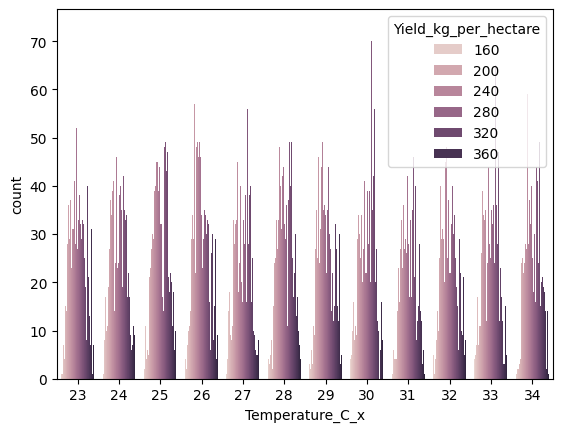

In [11]:
sns.countplot(x=df['Temperature_C_x'], hue=df['Yield_kg_per_hectare'])
plt.show()


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("\nModel Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Model Performance:
MAE: 0.11609218277344371
R2 Score: 0.9964384449879861


In [16]:
sample = [[900, 26, 75, 40, 35, 30, 5]]
prediction = model.predict(sample)

print("\nSample Prediction:")
print("Input: Rainfall=900, Temp=26, Humidity=75, NPK=40,35,30, Area=5")
print("Predicted Yield:", prediction[0])


Sample Prediction:
Input: Rainfall=900, Temp=26, Humidity=75, NPK=40,35,30, Area=5
Predicted Yield: 265.08


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [17]:
pickle.dump(model, open("soybean_model.pkl", "wb"))

print("\nModel saved successfully as soybean_model.pkl")


Model saved successfully as soybean_model.pkl
